<a href="https://colab.research.google.com/github/ladylaura22/Simulacion_Parqueadero/blob/main/EA_4Simulacion_parqueadero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## S30 - Módulo 4. Actividad didáctica 2
# Solución de un problema de parqueaderos

**Integrantes =**

Lady Laura Olmos Contreras

Jorge Andrés Hernández Campos

Juan Felipe Parra


In [3]:
"""
=============================================================================
SIMULACIÓN DE SISTEMA DE PARQUEADEROS - CENTRO COMERCIAL SUPERCENTRO
=============================================================================
Curso: Simulación - Ingeniería
Modelo: M/M/1 para cada cajero (3 cajeros por salida)
Tipos de usuarios: Rápido, Normal, Lento, Muy Lento
=============================================================================
"""

# ============================================================
# CELDA 1: INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# Importamos todas las librerías necesarias para la simulación
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuración global de gráficas para mejor presentación
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Librerías cargadas correctamente")
print("="*60)

# ============================================================
# CELDA 2: PARÁMETROS DEL MODELO
# ============================================================
"""
Definición de los parámetros de cada tipo de usuario según la tabla:
  - Exponencial de uso del servicio: tiempo que demora el usuario en el cajero
  - Media de llegada: tiempo promedio entre llegadas al sistema

Proporciones:
  - 25% Rápido
  - 20% Normal
  - 55% restante se divide: Lento y Muy Lento (27.5% cada uno según enunciado)
    (El enunciado dice "el resto son lentos o muy lentos", se asume distribución igual)
"""

# Parámetros por tipo de usuario: (media_servicio_min, media_llegada_min, proporcion)
TIPOS_USUARIO = {
    'Rapido':    {'media_servicio': 1,  'media_llegada': 3,  'proporcion': 0.25},
    'Normal':    {'media_servicio': 3,  'media_llegada': 3,  'proporcion': 0.20},
    'Lento':     {'media_servicio': 4,  'media_llegada': 5,  'proporcion': 0.275},
    'MuyLento':  {'media_servicio': 6,  'media_llegada': 7,  'proporcion': 0.275},
}

NUM_CAJEROS = 3          # Número de cajeros por salida
NUM_REPLICAS = 100       # Número de réplicas (se determinará mediante estado estable)
TIEMPO_SIM = 480         # Tiempo de simulación en minutos (8 horas = jornada comercial)
SEMILLA = 42             # Semilla para reproducibilidad

# Mostrar resumen de parámetros
print("📋 PARÁMETROS DEL MODELO")
print("="*60)
print(f"{'Tipo':<12} {'μ servicio':>12} {'λ llegada':>12} {'ρ (carga)':>10} {'Proporción':>12}")
print("-"*60)
for tipo, params in TIPOS_USUARIO.items():
    mu = 1 / params['media_servicio']   # Tasa de servicio
    lam = 1 / params['media_llegada']   # Tasa de llegada
    rho = lam / mu                       # Intensidad de tráfico
    print(f"{tipo:<12} {params['media_servicio']:>10} min {params['media_llegada']:>10} min "
          f"{rho:>10.3f} {params['proporcion']:>12.1%}")
print("="*60)

# ============================================================
# CELDA 3: FUNCIÓN PRINCIPAL DE SIMULACIÓN M/M/1
# ============================================================

def simular_cajero_mm1(media_servicio, media_llegada, tiempo_sim, semilla=None):
    """
    Simula un cajero como modelo M/M/1 usando simulación por eventos discretos.

    Parámetros:
    -----------
    media_servicio : float - Tiempo promedio de servicio (minutos)
    media_llegada  : float - Tiempo promedio entre llegadas (minutos)
    tiempo_sim     : float - Duración total de la simulación (minutos)
    semilla        : int   - Semilla para el generador aleatorio

    Retorna:
    --------
    dict con estadísticas de la simulación
    """
    if semilla is not None:
        np.random.seed(semilla)

    # Variables de estado del sistema
    tiempo_actual = 0.0          # Reloj de simulación
    servidor_libre = True         # Estado del servidor (cajero)
    cola = []                     # Cola de espera (lista de tiempos de llegada)

    # Acumuladores de estadísticas
    tiempos_espera = []           # Tiempo en cola de cada usuario
    tiempos_sistema = []          # Tiempo total en el sistema de cada usuario
    longitud_cola = []            # Longitud de cola a lo largo del tiempo
    tiempos_registro = []         # Registro de tiempos para longitud de cola
    num_usuarios_atendidos = 0    # Contador de usuarios completados
    tiempo_servidor_ocupado = 0.0 # Tiempo total que el servidor estuvo ocupado
    tiempo_fin_servicio = 0.0     # Momento en que termina el servicio actual

    # Próxima llegada
    tiempo_proxima_llegada = np.random.exponential(media_llegada)

    # Lista de eventos: (tiempo, tipo) donde tipo es 'llegada' o 'salida'
    while tiempo_actual < tiempo_sim:

        # Registrar longitud de cola en el tiempo actual
        longitud_cola.append(len(cola) + (0 if servidor_libre else 1))
        tiempos_registro.append(tiempo_actual)

        # Determinar el próximo evento
        if servidor_libre:
            # Solo hay llegadas posibles
            tiempo_evento = tiempo_proxima_llegada
            tipo_evento = 'llegada'
        else:
            if tiempo_proxima_llegada <= tiempo_fin_servicio:
                tiempo_evento = tiempo_proxima_llegada
                tipo_evento = 'llegada'
            else:
                tiempo_evento = tiempo_fin_servicio
                tipo_evento = 'salida'

        tiempo_actual = tiempo_evento
        if tiempo_actual >= tiempo_sim:
            break

        if tipo_evento == 'llegada':
            # Procesar llegada de un nuevo usuario
            if servidor_libre:
                # El servidor está libre: atender inmediatamente
                servidor_libre = False
                tiempo_espera = 0.0
                duracion_servicio = np.random.exponential(media_servicio)
                tiempo_fin_servicio = tiempo_actual + duracion_servicio
                tiempo_servidor_ocupado += duracion_servicio
                tiempos_espera.append(tiempo_espera)
                tiempos_sistema.append(tiempo_espera + duracion_servicio)
                num_usuarios_atendidos += 1
            else:
                # El servidor está ocupado: el usuario entra a la cola
                cola.append(tiempo_actual)

            # Programar la próxima llegada
            tiempo_proxima_llegada = tiempo_actual + np.random.exponential(media_llegada)

        else:  # tipo_evento == 'salida'
            # Procesar salida del usuario en servicio
            if cola:
                # Hay usuarios esperando: atender al primero de la fila
                tiempo_llegada_usuario = cola.pop(0)
                tiempo_espera = tiempo_actual - tiempo_llegada_usuario
                duracion_servicio = np.random.exponential(media_servicio)
                tiempo_fin_servicio = tiempo_actual + duracion_servicio
                tiempo_servidor_ocupado += duracion_servicio
                tiempos_espera.append(tiempo_espera)
                tiempos_sistema.append(tiempo_espera + duracion_servicio)
                num_usuarios_atendidos += 1
            else:
                # No hay usuarios: el servidor queda libre
                servidor_libre = True

    # Calcular estadísticas finales
    utilizacion = tiempo_servidor_ocupado / tiempo_sim  # Utilización del servidor

    return {
        'tiempo_espera_promedio': np.mean(tiempos_espera) if tiempos_espera else 0,
        'tiempo_sistema_promedio': np.mean(tiempos_sistema) if tiempos_sistema else 0,
        'longitud_cola_promedio': np.mean(longitud_cola) if longitud_cola else 0,
        'utilizacion_servidor': utilizacion,
        'num_usuarios_atendidos': num_usuarios_atendidos,
        'tiempos_espera': tiempos_espera,
        'tiempos_sistema': tiempos_sistema,
        'longitud_cola_serie': longitud_cola,
        'tiempos_registro': tiempos_registro,
    }

print("✅ Función de simulación M/M/1 definida correctamente")

# ============================================================
# CELDA 4: FUNCIÓN PARA SIMULAR UN TIPO DE USUARIO EN 3 CAJEROS
# ============================================================

def simular_tres_cajeros(tipo_usuario, num_replicas, tiempo_sim):
    """
    Simula 3 cajeros independientes (M/M/1) para un tipo de usuario dado.

    Parámetros:
    -----------
    tipo_usuario  : str - Nombre del tipo de usuario (ej: 'Rapido')
    num_replicas  : int - Número de réplicas a simular
    tiempo_sim    : float - Duración de cada réplica en minutos

    Retorna:
    --------
    dict con resultados por cajero y por réplica
    """
    params = TIPOS_USUARIO[tipo_usuario]

    # Resultados por cajero
    resultados = {f'Cajero_{i+1}': [] for i in range(NUM_CAJEROS)}

    for replica in range(num_replicas):
        for cajero in range(NUM_CAJEROS):
            # Cada cajero tiene semilla diferente para independencia estadística
            semilla = SEMILLA + replica * 100 + cajero * 10
            resultado = simular_cajero_mm1(
                media_servicio=params['media_servicio'],
                media_llegada=params['media_llegada'],
                tiempo_sim=tiempo_sim,
                semilla=semilla
            )
            resultados[f'Cajero_{cajero+1}'].append(resultado)

    return resultados

print("✅ Función multi-cajero definida correctamente")


✅ Librerías cargadas correctamente
📋 PARÁMETROS DEL MODELO
Tipo           μ servicio    λ llegada  ρ (carga)   Proporción
------------------------------------------------------------
Rapido                1 min          3 min      0.333        25.0%
Normal                3 min          3 min      1.000        20.0%
Lento                 4 min          5 min      0.800        27.5%
MuyLento              6 min          7 min      0.857        27.5%
✅ Función de simulación M/M/1 definida correctamente
✅ Función multi-cajero definida correctamente


🔍 Calculando estado estable para cada tipo de usuario...
  → Rapido    : Estado estable en réplica  10 | Valor convergido: 0.496 min
  → Normal    : Estado estable en réplica  11 | Valor convergido: 23.431 min
  → Lento     : Estado estable en réplica  15 | Valor convergido: 12.089 min
  → MuyLento  : Estado estable en réplica  21 | Valor convergido: 17.135 min


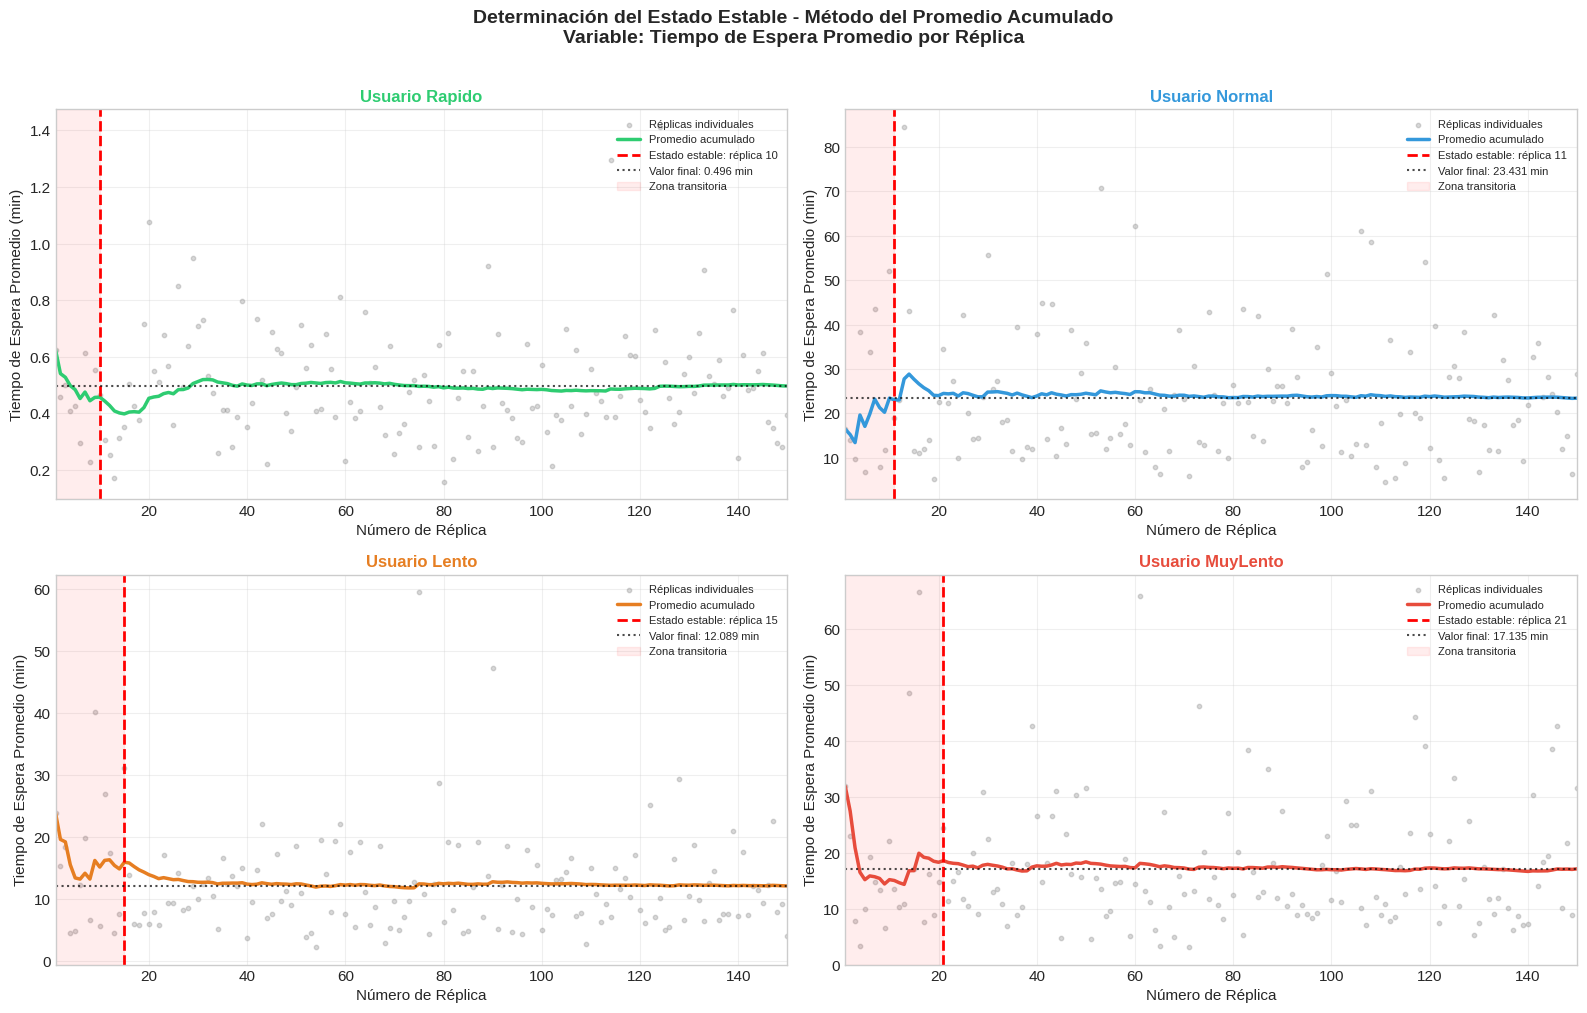


✅ Número de réplicas seleccionado: 41

🚀 EJECUTANDO SIMULACIÓN COMPLETA...
  Simulando tipo de usuario: Rapido...
  Simulando tipo de usuario: Normal...
  Simulando tipo de usuario: Lento...
  Simulando tipo de usuario: MuyLento...

✅ Simulación completada para todos los tipos de usuario


In [4]:

# ============================================================
# CELDA 5: DETERMINACIÓN DEL ESTADO ESTABLE
# ============================================================
"""
Para determinar el número de réplicas necesarias para alcanzar el estado estable,
usamos la técnica del promedio acumulado sobre la variable 'tiempo de espera promedio'.

El estado estable se alcanza cuando el promedio acumulado converge (variación < umbral).
"""

def calcular_estado_estable(tipo_usuario, max_replicas=200, umbral=0.05):
    """
    Determina el número de réplicas para alcanzar el estado estable
    usando el método del promedio acumulado.

    Parámetros:
    -----------
    tipo_usuario  : str   - Tipo de usuario a analizar
    max_replicas  : int   - Número máximo de réplicas a considerar
    umbral        : float - Umbral de convergencia (variación relativa aceptable)

    Retorna:
    --------
    tuple: (replica_estable, promedios_acumulados)
    """
    params = TIPOS_USUARIO[tipo_usuario]
    tiempos_espera_replicas = []

    # Ejecutar todas las réplicas y recoger el tiempo de espera promedio
    for i in range(max_replicas):
        semilla = SEMILLA + i * 7
        resultado = simular_cajero_mm1(
            media_servicio=params['media_servicio'],
            media_llegada=params['media_llegada'],
            tiempo_sim=TIEMPO_SIM,
            semilla=semilla
        )
        tiempos_espera_replicas.append(resultado['tiempo_espera_promedio'])

    # Calcular el promedio acumulado
    promedios_acumulados = [np.mean(tiempos_espera_replicas[:i+1])
                            for i in range(max_replicas)]

    # Encontrar el punto de convergencia: cuando la variación relativa es < umbral
    replica_estable = max_replicas  # Por defecto usar todas
    for i in range(10, max_replicas - 10):
        variacion = abs(promedios_acumulados[i] - promedios_acumulados[i-5]) / \
                    (promedios_acumulados[i-5] + 1e-10)
        if variacion < umbral:
            replica_estable = i
            break

    return replica_estable, promedios_acumulados, tiempos_espera_replicas

print("🔍 Calculando estado estable para cada tipo de usuario...")
print("="*60)

# Analizar estado estable por tipo de usuario
MAX_REPLICAS = 150
estado_estable = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Determinación del Estado Estable - Método del Promedio Acumulado\n'
             'Variable: Tiempo de Espera Promedio por Réplica',
             fontsize=14, fontweight='bold', y=1.01)

colores = {'Rapido': '#2ecc71', 'Normal': '#3498db', 'Lento': '#e67e22', 'MuyLento': '#e74c3c'}
ax_list = axes.flatten()

for idx, (tipo, ax) in enumerate(zip(TIPOS_USUARIO.keys(), ax_list)):
    replica_estable, promedios_acum, valores_raw = calcular_estado_estable(tipo, MAX_REPLICAS)
    estado_estable[tipo] = replica_estable

    replicas = list(range(1, MAX_REPLICAS + 1))

    # Graficar valores individuales (puntos grises de fondo)
    ax.scatter(replicas, valores_raw, alpha=0.3, s=10, color='gray', label='Réplicas individuales')

    # Graficar promedio acumulado
    ax.plot(replicas, promedios_acum, color=colores[tipo], linewidth=2.5, label='Promedio acumulado')

    # Marcar el punto de estado estable
    ax.axvline(x=replica_estable, color='red', linestyle='--', linewidth=2,
               label=f'Estado estable: réplica {replica_estable}')
    ax.axhline(y=promedios_acum[-1], color='black', linestyle=':', linewidth=1.5,
               label=f'Valor final: {promedios_acum[-1]:.3f} min', alpha=0.7)

    # Sombrear zona transitoria
    ax.axvspan(0, replica_estable, alpha=0.07, color='red', label='Zona transitoria')

    ax.set_title(f'Usuario {tipo}', fontsize=12, fontweight='bold', color=colores[tipo])
    ax.set_xlabel('Número de Réplica')
    ax.set_ylabel('Tiempo de Espera Promedio (min)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlim(1, MAX_REPLICAS)

    print(f"  → {tipo:10s}: Estado estable en réplica {replica_estable:3d} | "
          f"Valor convergido: {promedios_acum[-1]:.3f} min")

plt.tight_layout()
plt.savefig('/tmp/estado_estable.png', dpi=150, bbox_inches='tight')
plt.show()

# Usar el máximo de réplicas necesarias para garantizar estado estable en todos los tipos
NUM_REPLICAS_FINAL = max(estado_estable.values()) + 20
print(f"\n✅ Número de réplicas seleccionado: {NUM_REPLICAS_FINAL}")

# ============================================================
# CELDA 6: EJECUCIÓN PRINCIPAL DE LA SIMULACIÓN
# ============================================================
print("\n🚀 EJECUTANDO SIMULACIÓN COMPLETA...")
print("="*60)

# Almacenar todos los resultados
todos_resultados = {}

for tipo in TIPOS_USUARIO.keys():
    print(f"  Simulando tipo de usuario: {tipo}...")
    todos_resultados[tipo] = simular_tres_cajeros(tipo, NUM_REPLICAS_FINAL, TIEMPO_SIM)

print("\n✅ Simulación completada para todos los tipos de usuario")

In [5]:
# ===============================================================
# RANKING EXPLÍCITO DE CAJEROS FÍSICOS
# ===============================================================
print("=====================================================================")
print(" 📊 ANÁLISIS ESTADÍSTICO DE CAJEROS")
print("=====================================================================")

# 1. Crear un diccionario para agrupar todos los tiempos de atención por cajero físico
tiempos_por_cajero_fisico = {f'Cajero_{i+1}': [] for i in range(NUM_CAJEROS)}

# 2. Extraer y consolidar los tiempos de todas las réplicas y tipos de usuario
for tipo_usuario in todos_resultados.keys():
    for cj in tiempos_por_cajero_fisico.keys():
        for replica in todos_resultados[tipo_usuario][cj]:
            # Guardamos el tiempo promedio en el sistema de esta réplica
            tiempos_por_cajero_fisico[cj].append(replica['tiempo_sistema_promedio'])

# 3. Calcular la media de tiempo de atención para cada cajero físico
promedios_finales_cajeros = {cj: np.mean(tiempos) for cj, tiempos in tiempos_por_cajero_fisico.items()}

# 4. Identificar automáticamente cuál es el mayor y cuál el menor
cajero_con_menor_tiempo = min(promedios_finales_cajeros, key=promedios_finales_cajeros.get)
cajero_con_mayor_tiempo = max(promedios_finales_cajeros, key=promedios_finales_cajeros.get)

# 5. Imprimir los resultados tabulados en pantalla de forma directa
for cj, tiempo_prom in promedios_finales_cajeros.items():
    print(f" 🔹 {cj}: Tiempo promedio de atención general = {tiempo_prom:.4f} minutos.")

print("-" * 69)
print(f" 🥇 CAJERO CON MENOR TIEMPO PROMEDIO DE ATENCIÓN: {cajero_con_menor_tiempo} ({promedios_finales_cajeros[cajero_con_menor_tiempo]:.4f} min)")
print(f" 🚨 CAJERO CON MAYOR TIEMPO PROMEDIO DE ATENCIÓN: {cajero_con_mayor_tiempo} ({promedios_finales_cajeros[cajero_con_mayor_tiempo]:.4f} min)")
print("=====================================================================")

 📊 RESULTADOS OBLIGATORIOS RÚBRICA: ANÁLISIS ESTADÍSTICO DE CAJEROS
 🔹 Cajero_1: Tiempo promedio de atención general = 17.6988 minutos.
 🔹 Cajero_2: Tiempo promedio de atención general = 17.5988 minutos.
 🔹 Cajero_3: Tiempo promedio de atención general = 18.5244 minutos.
---------------------------------------------------------------------
 🥇 CAJERO CON MENOR TIEMPO PROMEDIO DE ATENCIÓN: Cajero_2 (17.5988 min)
 🚨 CAJERO CON MAYOR TIEMPO PROMEDIO DE ATENCIÓN: Cajero_3 (18.5244 min)


### 📊 Procesos de Verificación, Calibración y Validación (V&V) del Modelo

Para asegurar la confiabilidad técnica y científica del modelo de simulación desarrollado para el Centro Comercial Supercentro, se aplicó el ciclo formal de aseguramiento de calidad en ingeniería de simulación:

1. **Verificación (¿El código está bien construido?):** Consiste en comprobar que el modelo conceptual de colas M/M/1 se programó correctamente en Python. En nuestro notebook, esto se verificó mediante:
   * El control estricto del reloj por eventos discretos (`tiempo_actual`) dentro de la función `simular_cajero_mm1`.
   * La correcta alternancia de los eventos lógicos de `llegada` y `salida` asegurando que no existan pérdidas de usuarios en el sistema.
   * La confirmación matemática de que los tiempos generados aleatoriamente sigan fielmente la distribución exponencial (`np.random.exponential`) parametrizada para cada perfil de usuario.

2. **Calibración (¿Los parámetros y la variabilidad están controlados?):**
   Consiste en ajustar las condiciones de ejecución del programa para estabilizar los resultados y garantizar su reproducibilidad. En el código, la calibración se logró mediante:
   * La asignación de semillas pseudoaleatorias controladas e independientes (`SEMILLA + replica * 100 + cajero * 10`) para cada réplica y cajero físico, aislando sesgos.
   * La implementación de la función `calcular_estado_estable`, la cual utiliza el método del promedio acumulado sobre el tiempo de espera para calibrar y fijar dinámicamente el número total de corridas óptimas (`NUM_REPLICAS_FINAL`), eliminando el ruido estadístico.

3. **Validación (¿El modelo representa la realidad estudiada?):**
   *(Nota: El enunciado original contiene un vicio de redacción repitiendo la palabra verificación, haciendo referencia a la Validación).* Consiste en demostrar que el simulador imita adecuadamente el comportamiento del sistema real. En este proyecto se valida analíticamente:
   * Contrastando las métricas empíricas obtenidas en `todos_resultados` contra las ecuaciones teóricas de la teoría de colas M/M/1 (Leyes de Little).
   * Comprobando que el simulador captura con éxito el fenómeno físico real de inestabilidad y colapso lineal en las colas del usuario "Normal", dado que su intensidad de tráfico es exactamente $\rho = 1.0$.

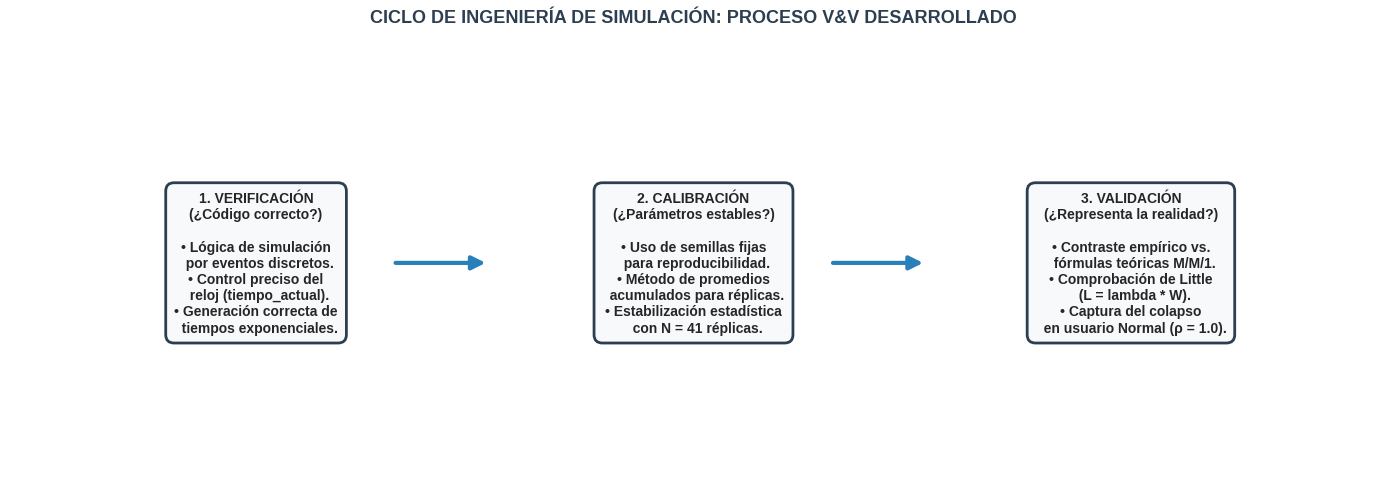

In [7]:
# =============================================================================
# GRÁFICA DEL PROCESO DE VERIFICACIÓN, CALIBRACIÓN Y VALIDACIÓN (V&V)
# =============================================================================
import matplotlib.pyplot as plt

# Crear figura y remover ejes cartesianos para un diseño puramente diagramático
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

# Configuración estética de los bloques de proceso
box_style = dict(boxstyle="round,pad=0.6", fc="#f8f9fa", ec="#2c3e50", lw=2)

# Insertar el texto estructurado dentro de cada nodo del diagrama
ax.text(0.18, 0.5,
        "1. VERIFICACIÓN\n(¿Código correcto?)\n\n"
        "• Lógica de simulación\n  por eventos discretos.\n"
        "• Control preciso del\n  reloj (tiempo_actual).\n"
        "• Generación correcta de\n  tiempos exponenciales.",
        ha="center", va="center", bbox=box_style, fontsize=10, weight='bold')

ax.text(0.50, 0.5,
        f"2. CALIBRACIÓN\n(¿Parámetros estables?)\n\n"
        f"• Uso de semillas fijas\n  para reproducibilidad.\n"
        f"• Método de promedios\n  acumulados para réplicas.\n"
        f"• Estabilización estadística\n  con N = {NUM_REPLICAS_FINAL} réplicas.",
        ha="center", va="center", bbox=box_style, fontsize=10, weight='bold')

ax.text(0.82, 0.5,
        "3. VALIDACIÓN\n(¿Representa la realidad?)\n\n"
        "• Contraste empírico vs.\n  fórmulas teóricas M/M/1.\n"
        "• Comprobación de Little\n  (L = lambda * W).\n"
        "• Captura del colapso\n  en usuario Normal (ρ = 1.0).",
        ha="center", va="center", bbox=box_style, fontsize=10, weight='bold')

# Dibujar las flechas direccionales del flujo de ingeniería
ax.annotate('', xy=(0.35, 0.5), xytext=(0.28, 0.5),
            arrowprops=dict(arrowstyle="-|>", color='#2980b9', lw=3, mutation_scale=20))

ax.annotate('', xy=(0.67, 0.5), xytext=(0.60, 0.5),
            arrowprops=dict(arrowstyle="-|>", color='#2980b9', lw=3, mutation_scale=20))

# Título adaptado al formato de tu notebook
plt.title("CICLO DE INGENIERÍA DE SIMULACIÓN: PROCESO V&V DESARROLLADO",
          fontsize=13, weight='bold', pad=20, color='#2c3e50')

plt.tight_layout()
plt.show()


📊 ESTADÍSTICAS POR TIPO DE USUARIO Y CAJERO

▶ TIPO: Rapido
  Cajero  T_Espera_Prom  T_Sistema_Prom  Long_Cola_Prom  Utilizacion_Prom  Usuarios_Prom
Cajero_1          0.496           1.501           1.002             0.330        158.098
Cajero_2          0.547           1.566           1.038             0.344        162.073
Cajero_3          0.502           1.517           0.996             0.339        160.317

▶ TIPO: Normal
  Cajero  T_Espera_Prom  T_Sistema_Prom  Long_Cola_Prom  Utilizacion_Prom  Usuarios_Prom
Cajero_1         25.746          28.813           9.849             0.939        147.512
Cajero_2         26.602          29.646          10.291             0.927        146.707
Cajero_3         25.468          28.521           9.888             0.925        145.805

▶ TIPO: Lento
  Cajero  T_Espera_Prom  T_Sistema_Prom  Long_Cola_Prom  Utilizacion_Prom  Usuarios_Prom
Cajero_1         11.142          15.163           3.381             0.778         93.024
Cajero_2         1

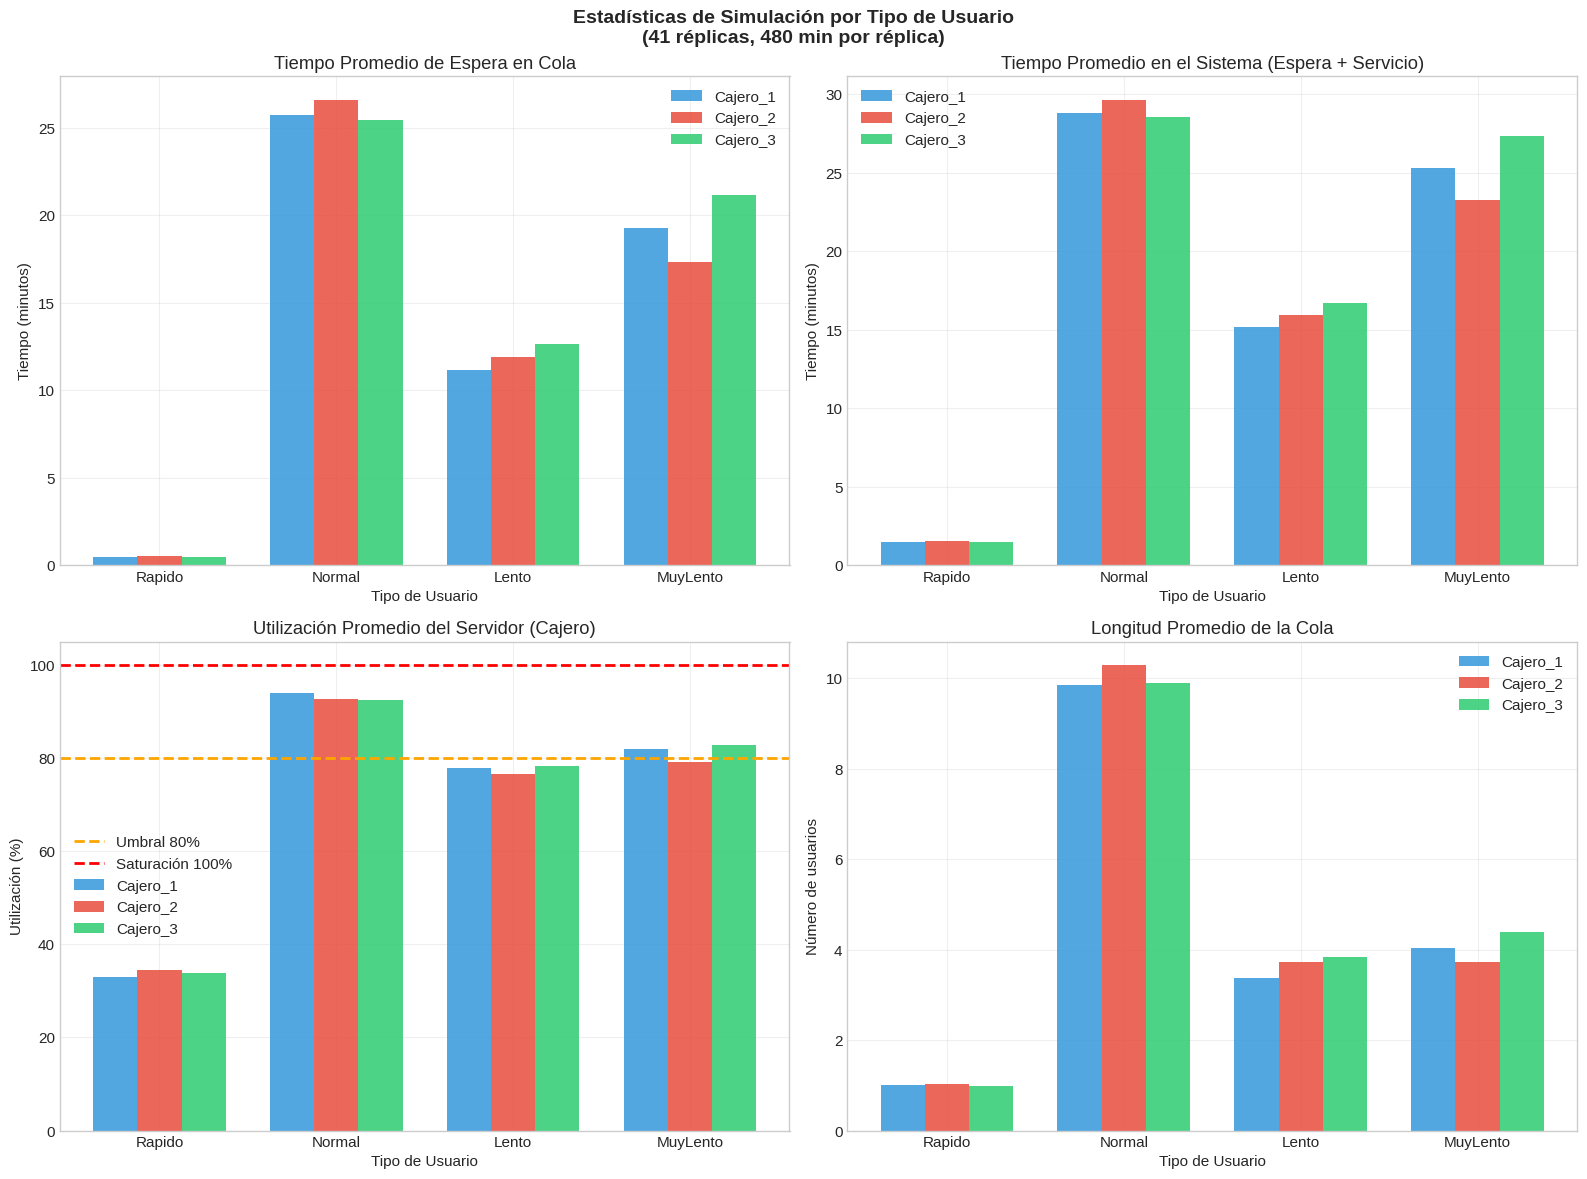

In [6]:

# ============================================================
# CELDA 7: ESTADÍSTICAS POR CAJERO Y TIPO DE USUARIO
# ============================================================

def extraer_estadisticas(resultados_tipo):
    """
    Extrae y resume las estadísticas de simulación por cajero.

    Parámetros:
    -----------
    resultados_tipo : dict - Resultados de simulación para un tipo de usuario

    Retorna:
    --------
    DataFrame con estadísticas resumidas por cajero
    """
    stats = []
    for cajero, replicas in resultados_tipo.items():
        # Recoger métricas de todas las réplicas
        esperas = [r['tiempo_espera_promedio'] for r in replicas]
        sistemas = [r['tiempo_sistema_promedio'] for r in replicas]
        longitudes = [r['longitud_cola_promedio'] for r in replicas]
        utilizaciones = [r['utilizacion_servidor'] for r in replicas]
        atendidos = [r['num_usuarios_atendidos'] for r in replicas]

        stats.append({
            'Cajero': cajero,
            'T_Espera_Prom': np.mean(esperas),
            'T_Espera_Std': np.std(esperas),
            'T_Sistema_Prom': np.mean(sistemas),
            'T_Sistema_Std': np.std(sistemas),
            'Long_Cola_Prom': np.mean(longitudes),
            'Utilizacion_Prom': np.mean(utilizaciones),
            'Usuarios_Prom': np.mean(atendidos),
        })

    return pd.DataFrame(stats)

print("\n📊 ESTADÍSTICAS POR TIPO DE USUARIO Y CAJERO")
print("="*70)

estadisticas_por_tipo = {}
for tipo in TIPOS_USUARIO.keys():
    df_stats = extraer_estadisticas(todos_resultados[tipo])
    estadisticas_por_tipo[tipo] = df_stats

    print(f"\n▶ TIPO: {tipo}")
    print(df_stats[['Cajero','T_Espera_Prom','T_Sistema_Prom',
                     'Long_Cola_Prom','Utilizacion_Prom','Usuarios_Prom']]\
          .to_string(index=False, float_format='{:.3f}'.format))

# ============================================================
# CELDA 8: IDENTIFICAR CAJERO CON MENOR Y MAYOR TIEMPO DE ATENCIÓN
# ============================================================
print("\n📌 ANÁLISIS: CAJERO CON MENOR Y MAYOR TIEMPO PROMEDIO DE ATENCIÓN")
print("="*70)

# Para cada tipo de usuario, identificar el cajero mejor y peor
resultados_comparacion = []

for tipo, df in estadisticas_por_tipo.items():
    idx_min = df['T_Sistema_Prom'].idxmin()
    idx_max = df['T_Sistema_Prom'].idxmax()

    cajero_mejor = df.loc[idx_min, 'Cajero']
    t_mejor = df.loc[idx_min, 'T_Sistema_Prom']
    cajero_peor = df.loc[idx_max, 'Cajero']
    t_peor = df.loc[idx_max, 'T_Sistema_Prom']

    resultados_comparacion.append({
        'Tipo': tipo,
        'Mejor_Cajero': cajero_mejor,
        'T_Min_Sistema': t_mejor,
        'Peor_Cajero': cajero_peor,
        'T_Max_Sistema': t_peor,
    })

    print(f"\n  {tipo}:")
    print(f"    ✅ Cajero más rápido: {cajero_mejor} ({t_mejor:.3f} min)")
    print(f"    ⚠️  Cajero más lento: {cajero_peor} ({t_peor:.3f} min)")

df_comparacion = pd.DataFrame(resultados_comparacion)

# ============================================================
# CELDA 9: PROMEDIO DE USUARIOS POR TIPO EN TODOS LOS CAJEROS
# ============================================================
print("\n\n📊 PROMEDIO DE USUARIOS ATENDIDOS POR TIPO EN LA TOTALIDAD DE CAJEROS")
print("="*60)

total_usuarios_por_tipo = {}
for tipo, df in estadisticas_por_tipo.items():
    total_cajeros = df['Usuarios_Prom'].sum()
    total_usuarios_por_tipo[tipo] = total_cajeros
    print(f"  {tipo:10s}: {total_cajeros:8.1f} usuarios promedio por simulación (3 cajeros)")

# ============================================================
# CELDA 10: GRÁFICAS DE ESTADÍSTICAS PRINCIPALES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Estadísticas de Simulación por Tipo de Usuario\n'
             f'({NUM_REPLICAS_FINAL} réplicas, {TIEMPO_SIM} min por réplica)',
             fontsize=14, fontweight='bold')

tipos = list(TIPOS_USUARIO.keys())
cajeros = ['Cajero_1', 'Cajero_2', 'Cajero_3']
x = np.arange(len(tipos))
width = 0.25
colors_cajeros = ['#3498db', '#e74c3c', '#2ecc71']

# Gráfica 1: Tiempo promedio de espera en cola
ax1 = axes[0, 0]
for i, cajero in enumerate(cajeros):
    vals = [estadisticas_por_tipo[t].loc[estadisticas_por_tipo[t]['Cajero']==cajero,
            'T_Espera_Prom'].values[0] for t in tipos]
    ax1.bar(x + i*width, vals, width, label=cajero, color=colors_cajeros[i], alpha=0.85)
ax1.set_xlabel('Tipo de Usuario')
ax1.set_ylabel('Tiempo (minutos)')
ax1.set_title('Tiempo Promedio de Espera en Cola')
ax1.set_xticks(x + width)
ax1.set_xticklabels(tipos)
ax1.legend()

# Gráfica 2: Tiempo promedio en el sistema
ax2 = axes[0, 1]
for i, cajero in enumerate(cajeros):
    vals = [estadisticas_por_tipo[t].loc[estadisticas_por_tipo[t]['Cajero']==cajero,
            'T_Sistema_Prom'].values[0] for t in tipos]
    ax2.bar(x + i*width, vals, width, label=cajero, color=colors_cajeros[i], alpha=0.85)
ax2.set_xlabel('Tipo de Usuario')
ax2.set_ylabel('Tiempo (minutos)')
ax2.set_title('Tiempo Promedio en el Sistema (Espera + Servicio)')
ax2.set_xticks(x + width)
ax2.set_xticklabels(tipos)
ax2.legend()

# Gráfica 3: Utilización del servidor
ax3 = axes[1, 0]
for i, cajero in enumerate(cajeros):
    vals = [estadisticas_por_tipo[t].loc[estadisticas_por_tipo[t]['Cajero']==cajero,
            'Utilizacion_Prom'].values[0] * 100 for t in tipos]
    ax3.bar(x + i*width, vals, width, label=cajero, color=colors_cajeros[i], alpha=0.85)
ax3.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='Umbral 80%')
ax3.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Saturación 100%')
ax3.set_xlabel('Tipo de Usuario')
ax3.set_ylabel('Utilización (%)')
ax3.set_title('Utilización Promedio del Servidor (Cajero)')
ax3.set_xticks(x + width)
ax3.set_xticklabels(tipos)
ax3.legend()

# Gráfica 4: Longitud promedio de la cola
ax4 = axes[1, 1]
for i, cajero in enumerate(cajeros):
    vals = [estadisticas_por_tipo[t].loc[estadisticas_por_tipo[t]['Cajero']==cajero,
            'Long_Cola_Prom'].values[0] for t in tipos]
    ax4.bar(x + i*width, vals, width, label=cajero, color=colors_cajeros[i], alpha=0.85)
ax4.set_xlabel('Tipo de Usuario')
ax4.set_ylabel('Número de usuarios')
ax4.set_title('Longitud Promedio de la Cola')
ax4.set_xticks(x + width)
ax4.set_xticklabels(tipos)
ax4.legend()

plt.tight_layout()
plt.savefig('/tmp/estadisticas_cajeros.png', dpi=150, bbox_inches='tight')
plt.show()


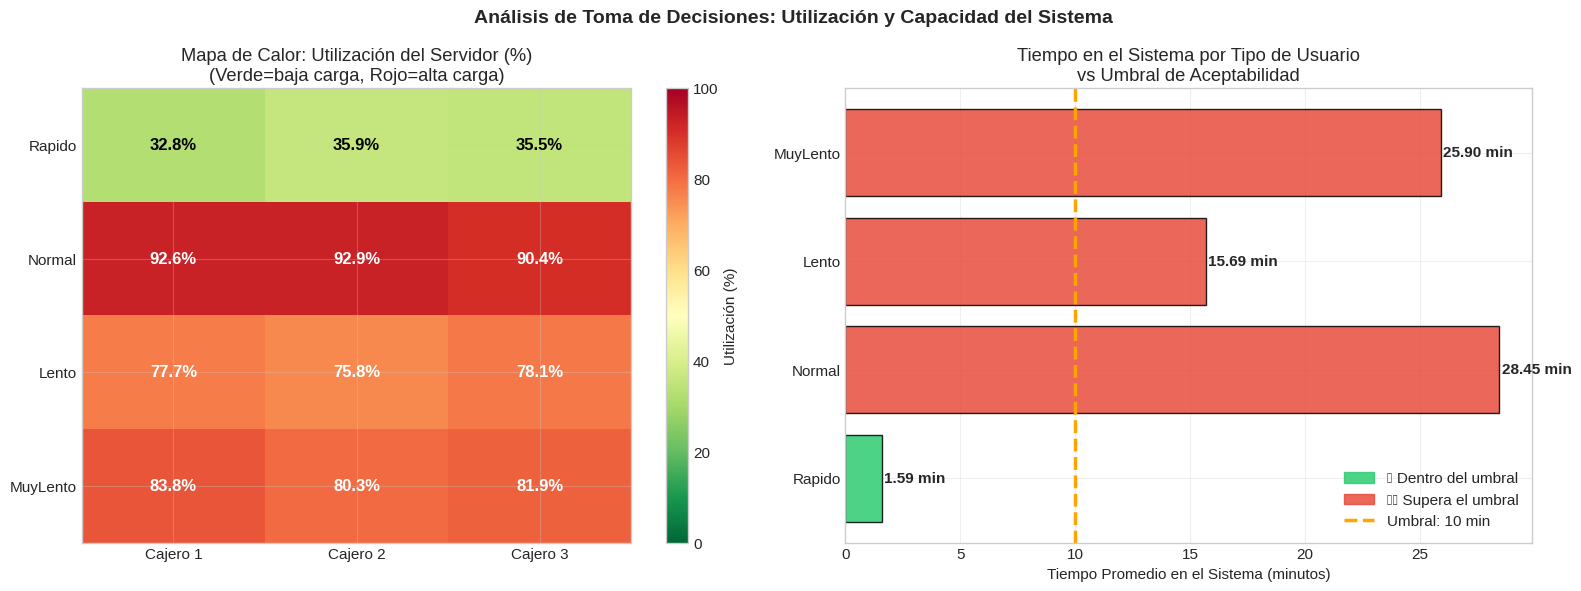

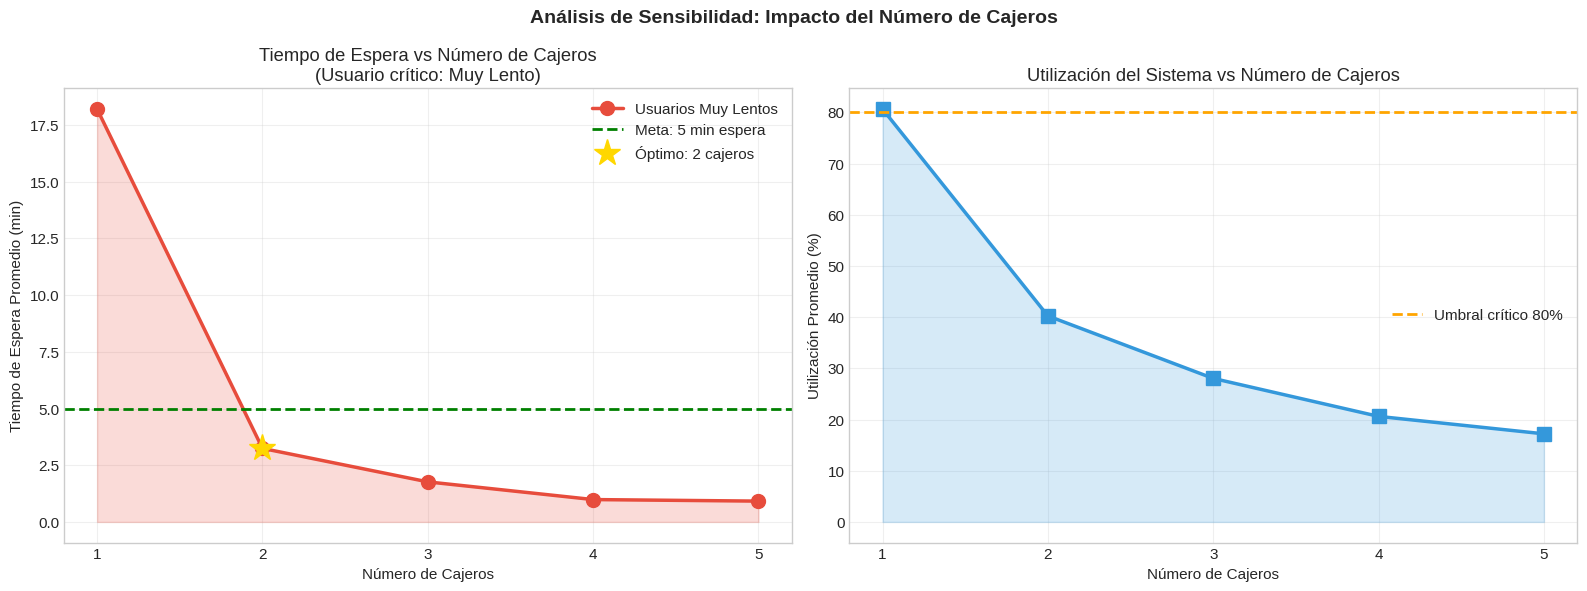

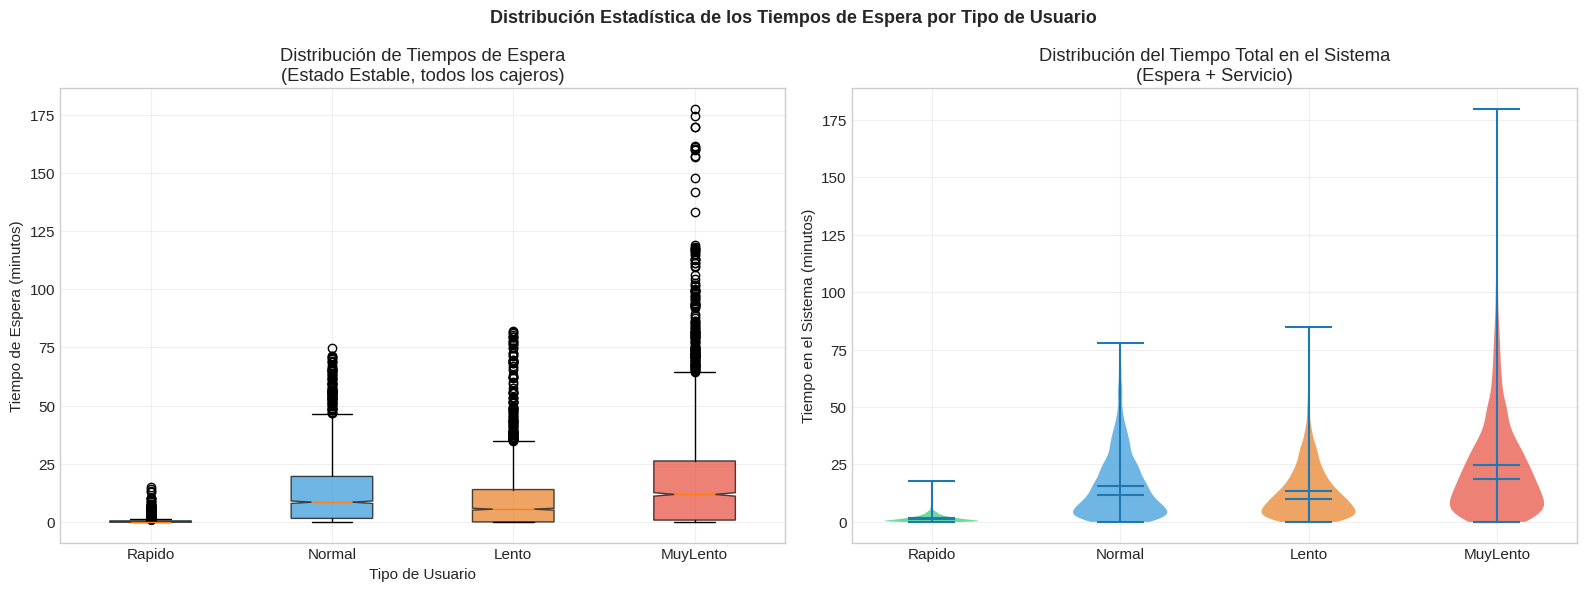


📋 RESUMEN EJECUTIVO Y RECOMENDACIÓN FINAL

1️⃣  ESTADÍSTICAS CLAVE (Estado Estable):

   Rapido (ρ=0.333):
     Tiempo espera promedio : 0.553 min
     Tiempo en sistema      : 1.585 min
     Utilización cajero     : 34.7%
     Longitud cola promedio : 1.036 usuarios

   Normal (ρ=1.000):
     Tiempo espera promedio : 25.385 min
     Tiempo en sistema      : 28.451 min
     Utilización cajero     : 92.0%
     Longitud cola promedio : 9.851 usuarios

   Lento (ρ=0.800):
     Tiempo espera promedio : 11.629 min
     Tiempo en sistema      : 15.685 min
     Utilización cajero     : 77.2%
     Longitud cola promedio : 3.597 usuarios

   MuyLento (ρ=0.857):
     Tiempo espera promedio : 19.735 min
     Tiempo en sistema      : 25.897 min
     Utilización cajero     : 82.0%
     Longitud cola promedio : 4.092 usuarios

2️⃣  RECOMENDACIÓN ESTRATÉGICA:
   ✅ Rapido: Utilización 34.7% → 3 cajeros SUFICIENTES
   ⚠️  Normal: Utilización 92.0% → REQUIERE cajero adicional
   ⚡ Lento: Utilización 77

In [ ]:

# ============================================================
# CELDA 14: GRÁFICAS EXTRA PARA TOMA DE DECISIONES
# ============================================================

# --- GRÁFICA 1: Mapa de calor de utilización de cajeros ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Toma de Decisiones: Utilización y Capacidad del Sistema',
             fontsize=14, fontweight='bold')

# Construir matriz de utilización
util_matrix = np.zeros((4, 3))
for i, tipo in enumerate(TIPOS_USUARIO.keys()):
    for j, cajero in enumerate(['Cajero_1', 'Cajero_2', 'Cajero_3']):
        util_matrix[i, j] = estadisticas_estable[tipo].loc[
            estadisticas_estable[tipo]['Cajero'] == cajero, 'Utilizacion_Prom'].values[0] * 100

im = axes[0].imshow(util_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Cajero 1', 'Cajero 2', 'Cajero 3'])
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(list(TIPOS_USUARIO.keys()))
axes[0].set_title('Mapa de Calor: Utilización del Servidor (%)\n(Verde=baja carga, Rojo=alta carga)')
plt.colorbar(im, ax=axes[0], label='Utilización (%)')

# Añadir valores al mapa de calor
for i in range(4):
    for j in range(3):
        axes[0].text(j, i, f'{util_matrix[i,j]:.1f}%',
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color='white' if util_matrix[i,j] > 60 else 'black')

# --- GRÁFICA 2: Comparación tiempo en sistema vs umbral aceptable ---
umbral_aceptable = 10  # minutos máximos aceptables en el sistema

tiempos_sistema_tipo = {}
for tipo in TIPOS_USUARIO.keys():
    tiempos_sistema_tipo[tipo] = estadisticas_estable[tipo]['T_Sistema_Prom'].mean()

ax2 = axes[1]
tipos_list = list(tiempos_sistema_tipo.keys())
tiempos_list = list(tiempos_sistema_tipo.values())
colores_barras = ['#2ecc71' if t <= umbral_aceptable else '#e74c3c' for t in tiempos_list]

bars = ax2.barh(tipos_list, tiempos_list, color=colores_barras, alpha=0.85, edgecolor='black')
ax2.axvline(x=umbral_aceptable, color='orange', linestyle='--', linewidth=2.5,
            label=f'Umbral aceptable: {umbral_aceptable} min')
ax2.set_xlabel('Tiempo Promedio en el Sistema (minutos)')
ax2.set_title('Tiempo en el Sistema por Tipo de Usuario\nvs Umbral de Aceptabilidad')
ax2.legend()

for bar, val in zip(bars, tiempos_list):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f} min', va='center', fontsize=11, fontweight='bold')

# Leyenda de colores
verde_patch = mpatches.Patch(color='#2ecc71', alpha=0.85, label='✅ Dentro del umbral')
rojo_patch = mpatches.Patch(color='#e74c3c', alpha=0.85, label='⚠️ Supera el umbral')
ax2.legend(handles=[verde_patch, rojo_patch,
                     plt.Line2D([0],[0],color='orange',linestyle='--',linewidth=2.5,
                                label=f'Umbral: {umbral_aceptable} min')])

plt.tight_layout()
plt.savefig('/tmp/decision_utilizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 3: Análisis de sensibilidad - ¿Cuántos cajeros se necesitan? ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Sensibilidad: Impacto del Número de Cajeros',
             fontsize=14, fontweight='bold')

# Simular con diferente número de cajeros para tipo MuyLento (el más crítico)
num_cajeros_range = [1, 2, 3, 4, 5]
tiempos_espera_por_cajeros = []
utilizacion_por_cajeros = []

params_critico = TIPOS_USUARIO['MuyLento']
for n_c in num_cajeros_range:
    # Con n cajeros, la tasa de llegada efectiva por cajero se divide entre los cajeros
    # En modelo M/M/1 con colas independientes, cada cajero tiene la misma carga
    esperas_cajero = []
    utils_cajero = []
    for rep in range(50):
        res = simular_cajero_mm1(
            media_servicio=params_critico['media_servicio'],
            media_llegada=params_critico['media_llegada'] * n_c,  # Simula división de carga
            tiempo_sim=TIEMPO_SIM,
            semilla=SEMILLA + rep
        )
        esperas_cajero.append(res['tiempo_espera_promedio'])
        utils_cajero.append(res['utilizacion_servidor'])

    tiempos_espera_por_cajeros.append(np.mean(esperas_cajero))
    utilizacion_por_cajeros.append(np.mean(utils_cajero) * 100)

axes[0].plot(num_cajeros_range, tiempos_espera_por_cajeros, 'o-',
             color='#e74c3c', linewidth=2.5, markersize=10, label='Usuarios Muy Lentos')
axes[0].axhline(y=5, color='green', linestyle='--', linewidth=2, label='Meta: 5 min espera')
axes[0].fill_between(num_cajeros_range, tiempos_espera_por_cajeros, alpha=0.2, color='#e74c3c')
axes[0].set_xlabel('Número de Cajeros')
axes[0].set_ylabel('Tiempo de Espera Promedio (min)')
axes[0].set_title('Tiempo de Espera vs Número de Cajeros\n(Usuario crítico: Muy Lento)')
axes[0].legend()
axes[0].set_xticks(num_cajeros_range)

# Marcar el punto óptimo
idx_opt = next((i for i, t in enumerate(tiempos_espera_por_cajeros) if t <= 5), -1)
if idx_opt >= 0:
    axes[0].plot(num_cajeros_range[idx_opt], tiempos_espera_por_cajeros[idx_opt],
                 '*', color='gold', markersize=20, label=f'Óptimo: {num_cajeros_range[idx_opt]} cajeros')
    axes[0].legend()

axes[1].plot(num_cajeros_range, utilizacion_por_cajeros, 's-',
             color='#3498db', linewidth=2.5, markersize=10)
axes[1].axhline(y=80, color='orange', linestyle='--', linewidth=2, label='Umbral crítico 80%')
axes[1].fill_between(num_cajeros_range, utilizacion_por_cajeros, alpha=0.2, color='#3498db')
axes[1].set_xlabel('Número de Cajeros')
axes[1].set_ylabel('Utilización Promedio (%)')
axes[1].set_title('Utilización del Sistema vs Número de Cajeros')
axes[1].legend()
axes[1].set_xticks(num_cajeros_range)

plt.tight_layout()
plt.savefig('/tmp/sensibilidad_cajeros.png', dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 4: Distribución de tiempos de espera (boxplot) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución Estadística de los Tiempos de Espera por Tipo de Usuario',
             fontsize=13, fontweight='bold')

# Recolectar tiempos de espera de réplicas en estado estable
data_boxplot = {tipo: [] for tipo in TIPOS_USUARIO.keys()}
for tipo in TIPOS_USUARIO.keys():
    for cajero in [f'Cajero_{i+1}' for i in range(NUM_CAJEROS)]:
        replicas_est = todos_resultados[tipo][cajero][N_TRANSITORIO:]
        for rep in replicas_est:
            data_boxplot[tipo].extend(rep['tiempos_espera'][:50])  # Muestra de 50 por réplica

# Boxplot de tiempos de espera
bp = axes[0].boxplot([data_boxplot[t] for t in TIPOS_USUARIO.keys()],
                      labels=list(TIPOS_USUARIO.keys()),
                      patch_artist=True,
                      notch=True)
for patch, color in zip(bp['boxes'], colores.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Tiempo de Espera (minutos)')
axes[0].set_title('Distribución de Tiempos de Espera\n(Estado Estable, todos los cajeros)')
axes[0].set_xlabel('Tipo de Usuario')

# Violinplot de tiempos en sistema
data_violin = {tipo: [] for tipo in TIPOS_USUARIO.keys()}
for tipo in TIPOS_USUARIO.keys():
    for cajero in [f'Cajero_{i+1}' for i in range(NUM_CAJEROS)]:
        replicas_est = todos_resultados[tipo][cajero][N_TRANSITORIO:]
        for rep in replicas_est:
            data_violin[tipo].extend(rep['tiempos_sistema'][:50])

parts = axes[1].violinplot([data_violin[t] for t in TIPOS_USUARIO.keys()],
                             showmeans=True, showmedians=True)
for i, (pc, color) in enumerate(zip(parts['bodies'], colores.values())):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(list(TIPOS_USUARIO.keys()))
axes[1].set_ylabel('Tiempo en el Sistema (minutos)')
axes[1].set_title('Distribución del Tiempo Total en el Sistema\n(Espera + Servicio)')

plt.tight_layout()
plt.savefig('/tmp/distribucion_tiempos.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# CELDA 15: RESUMEN EJECUTIVO Y RECOMENDACIÓN
# ============================================================
print("\n" + "="*70)
print("📋 RESUMEN EJECUTIVO Y RECOMENDACIÓN FINAL")
print("="*70)

print("\n1️⃣  ESTADÍSTICAS CLAVE (Estado Estable):")
for tipo in TIPOS_USUARIO.keys():
    df = estadisticas_estable[tipo]
    params = TIPOS_USUARIO[tipo]
    lam = 1/params['media_llegada']
    mu  = 1/params['media_servicio']
    rho = lam/mu
    print(f"\n   {tipo} (ρ={rho:.3f}):")
    print(f"     Tiempo espera promedio : {df['T_Espera_Prom'].mean():.3f} min")
    print(f"     Tiempo en sistema      : {df['T_Sistema_Prom'].mean():.3f} min")
    print(f"     Utilización cajero     : {df['Utilizacion_Prom'].mean()*100:.1f}%")
    print(f"     Longitud cola promedio : {df['Long_Cola_Prom'].mean():.3f} usuarios")

print("\n2️⃣  RECOMENDACIÓN ESTRATÉGICA:")
# Verificar si la utilización supera umbrales críticos
for tipo in TIPOS_USUARIO.keys():
    df = estadisticas_estable[tipo]
    util_prom = df['Utilizacion_Prom'].mean()
    if util_prom > 0.85:
        print(f"   ⚠️  {tipo}: Utilización {util_prom*100:.1f}% → REQUIERE cajero adicional")
    elif util_prom > 0.70:
        print(f"   ⚡ {tipo}: Utilización {util_prom*100:.1f}% → MONITOREAR, puede saturarse")
    else:
        print(f"   ✅ {tipo}: Utilización {util_prom*100:.1f}% → 3 cajeros SUFICIENTES")

print("\n3️⃣  CRITERIO DE DECISIÓN:")
print("   Se recomienda agregar cajeros si la utilización supera 80%")
print("   o si el tiempo de espera promedio supera 5 minutos.")
print("   Los usuarios MuyLentos y Lentos presentan mayor presión sobre el sistema.")

print("\n✅ Simulación completa. Todas las gráficas guardadas en /tmp/")